In [ ]:
# Martiros Saryan — Neural Style Transfer (VGG19 based)

# Mount Google Drive for accessing dataset and saving outputs
from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

# VGG19 model used for feature extraction in style transfer
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

# Print TensorFlow version for reproducibility
print("TensorFlow version:", tf.__version__)

# ---------------------------
# Dataset and output paths
# ---------------------------

# Path to content image (the image to be stylized)
CONTENT_PATH = "/content/drive/MyDrive/Martiros_Saryan/Content_landscapes/IMG_6915.JPG"

# Path to style image (painting style reference)
STYLE_PATH   = "/content/drive/MyDrive/Martiros_Saryan/Martiros_Saryan_A/A2.jpg"

# Path where final stylized output will be saved
OUTPUT_PATH  = "/content/drive/MyDrive/vgg19_nst_result.png"

Mounted at /content/drive
TensorFlow version: 2.19.0


In [ ]:
# Hyperparameters for Neural Style Transfer optimization

# Input image resolution
# Higher values improve quality but require more GPU memory
IMAGE_SIZE = 512

# Weight for content loss (preserves original structure)
CONTENT_WEIGHT = 8e2

# Weight for style loss (controls artistic transformation strength)
STYLE_WEIGHT = 5.0

# Total variation loss weight (encourages smoothness and reduces noise)
TV_WEIGHT = 2.0

# Number of training epochs (full optimization cycles)
EPOCHS = 50

# Number of optimization steps per epoch
# Total optimization steps = EPOCHS × STEPS_PER_EPOCH
STEPS_PER_EPOCH = 100

# Learning rate for gradient-based optimization
LEARNING_RATE = 0.01

In [ ]:
# Image loading and preprocessing utilities for Neural Style Transfer

def load_img(path, max_dim=512):
    """
    Loads an image from disk, resizes it while preserving aspect ratio,
    and converts it into a 4D tensor suitable for model input.
    """
    img = Image.open(path).convert("RGB")
    w, h = img.size

    # Compute scaling factor to fit the image within max_dim
    scale = max_dim / max(w, h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Resize image using high-quality Lanczos interpolation
    img = img.resize((new_w, new_h), Image.LANCZOS)

    # Convert image to NumPy array in float32 format
    img = np.array(img).astype(np.float32)

    # Add batch dimension for deep learning models
    img = np.expand_dims(img, axis=0)

    return tf.constant(img)


def preprocess_img(img):
    """
    Applies VGG19-specific preprocessing to normalize pixel values
    for feature extraction.
    """
    return preprocess_input(img)


def tensor_to_image(tensor):
    """
    Converts a tensor output back into a displayable image format.
    Removes batch dimension and clips pixel values to valid range.
    """
    x = tensor.numpy()

    # Remove batch dimension if present
    if len(x.shape) == 4:
        x = x[0]

    # Convert to valid image range
    x = np.clip(x, 0, 255).astype("uint8")

    return x

Content shape: (1, 511, 412, 3)
Style shape: (1, 507, 512, 3)


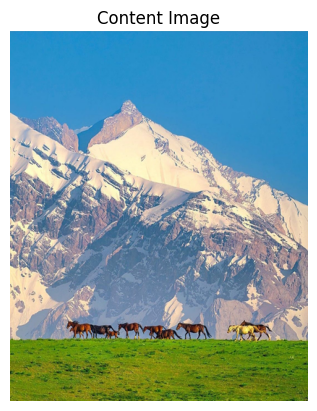

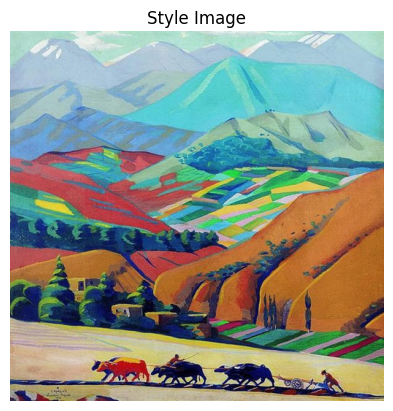

In [ ]:
# Utility function for displaying images during visualization

def imshow(img, title=None):
    """
    Displays a tensor or image array using matplotlib.
    Handles both batched and single-image inputs.
    """
    # Remove batch dimension if present
    if len(img.shape) == 4:
        img = img[0]

    # Convert tensor values to valid image format
    img = tf.cast(img, tf.uint8)

    # Display image
    plt.imshow(img)

    # Optional title for visualization
    if title:
        plt.title(title)

    plt.axis("off")
    plt.show()


# Load and preprocess content and style images
# These images will be used for computing content and style representations

content_image = load_img(CONTENT_PATH, IMAGE_SIZE)
style_image   = load_img(STYLE_PATH, IMAGE_SIZE)

# Print tensor shapes for verification
print("Content shape:", content_image.shape)
print("Style shape:", style_image.shape)

# Visualize loaded images for sanity check
imshow(tf.cast(content_image[0], tf.uint8), "Content Image")
imshow(tf.cast(style_image[0], tf.uint8), "Style Image")

In [ ]:
# VGG19 feature extraction layers for Neural Style Transfer

# Content representation is extracted from a deeper convolutional layer
# which captures high-level structure (objects and spatial layout)
content_layers = ['block5_conv2']

# Style representation is extracted from multiple layers
# to capture both low-level textures and high-level artistic patterns
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# Importance weights assigned to each style layer
# Deeper layers contribute more to global style patterns,
# while shallow layers capture fine textures
style_layer_weights = {
    'block1_conv1': 0.05,
    'block2_conv1': 0.1,
    'block3_conv1': 0.2,
    'block4_conv1': 0.3,
    'block5_conv1': 0.35,
}

# Number of layers used for content and style representation
num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

# ------------------------------------------------------------
# Build truncated VGG19 model for feature extraction
# ------------------------------------------------------------
def vgg_layers(layer_names):
    """
    Constructs a VGG19 model that outputs intermediate feature maps
    from selected layers for style and content representation.
    """
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False  # freeze weights for feature extraction

    outputs = [vgg.get_layer(name).output for name in layer_names]

    # Model returns activations from selected layers
    model = tf.keras.Model([vgg.input], outputs)
    return model


# ------------------------------------------------------------
# Gram Matrix computation (style representation)
# ------------------------------------------------------------
def gram_matrix(input_tensor):
    """
    Computes Gram matrix to capture correlations between feature maps.
    This is used as the core representation of "style".
    """
    # input shape: [batch, height, width, channels]

    # Compute feature correlations between channels
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)

    # Normalize by spatial dimensions
    input_shape = tf.shape(input_tensor)
    h = tf.cast(input_shape[1], tf.float32)
    w = tf.cast(input_shape[2], tf.float32)
    num_locations = h * w

    return result / num_locations

In [ ]:
# Neural network model for joint Style and Content feature extraction
# based on a truncated VGG19 architecture

class StyleContentModel(tf.keras.models.Model):
    """
    This model extracts both style and content representations
    from input images using a pre-trained VGG19 network.
    """

    def __init__(self, style_layers, content_layers):
        super().__init__()

        # Build VGG19 feature extractor using selected layers
        self.vgg = vgg_layers(style_layers + content_layers)

        self.style_layers = style_layers
        self.content_layers = content_layers

        # Number of style feature maps used in loss computation
        self.num_style_layers = len(style_layers)

        # Freeze VGG weights to prevent training
        self.vgg.trainable = False

    def call(self, inputs):
        """
        Forward pass:
        Extracts style and content features from input image tensor.
        """

        # Preprocess input according to VGG19 requirements
        inputs = preprocess_img(inputs)

        # Extract feature maps from selected layers
        outputs = self.vgg(inputs)

        # Split outputs into style and content features
        style_outputs = outputs[:self.num_style_layers]
        content_outputs = outputs[self.num_style_layers:]

        # Convert style feature maps into Gram matrices
        # to capture texture and correlation statistics
        style_outputs = [
            gram_matrix(style_output)
            for style_output in style_outputs
        ]

        # Map style features to corresponding layer names
        style_dict = {
            style_name: value
            for style_name, value in zip(self.style_layers, style_outputs)
        }

        # Map content features to corresponding layer names
        content_dict = {
            content_name: value
            for content_name, value in zip(self.content_layers, content_outputs)
        }

        # Return structured representation of style and content
        return {'style': style_dict, 'content': content_dict}


# Instantiate feature extractor model
# This will be used during optimization to compute losses
extractor = StyleContentModel(style_layers, content_layers)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

# Target feature representations

# These are the fixed reference features extracted from:
# - style image (for texture/style statistics)
# - content image (for structural information)

style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']



# Style and Content Loss Function

# This function computes the total optimization objective used
# in Neural Style Transfer. It combines:
# - Style loss (texture similarity via Gram matrices)
# - Content loss (high-level feature similarity)

def style_content_loss(outputs):
    """
    Computes total loss for neural style transfer optimization.

    Args:
        outputs: dictionary containing extracted style and content features
                 from the generated image.

    Returns:
        total_loss: combined optimization objective
        style_loss: style reconstruction loss
        content_loss: content reconstruction loss
    """

    style_outputs = outputs['style']
    content_outputs = outputs['content']


    # Style loss computation

    # Measures difference between Gram matrices of generated image
    # and style reference image. Each layer is weighted differently
    # to control contribution of texture scales.

    style_loss = tf.add_n([
        style_layer_weights[name] *
        tf.reduce_mean((style_outputs[name] - style_targets[name]) ** 2)
        for name in style_outputs.keys()
    ])

    # Global scaling factor for style contribution
    style_loss *= STYLE_WEIGHT



    # Content loss computation

    # Measures difference between deep feature activations
    # of generated image and content reference image.

    content_loss = tf.add_n([
        tf.reduce_mean((content_outputs[name] - content_targets[name]) ** 2)
        for name in content_outputs.keys()
    ])

    # Normalize content loss by number of content layers
    content_loss *= CONTENT_WEIGHT / num_content_layers



    # Total loss (optimization objective)

    total_loss = style_loss + content_loss

    return total_loss, style_loss, content_loss

In [ ]:

# Total Variation Loss

# This loss encourages spatial smoothness in the generated image.
# It reduces high-frequency noise and improves visual coherence.

def total_variation_loss(image):
    return tf.image.total_variation(image)



# Initialization of Generated Image

# The generated image is initialized as a combination of:
# - the content image (to preserve structure)
# - random noise (to allow exploration of style space)
#
# This helps the optimization avoid poor local minima.

# Alternative initialization (pure content image)
# generated_image = tf.Variable(content_image)

noise = tf.random.uniform(tf.shape(content_image), 0, 255)
generated_image = tf.Variable(0.7 * content_image + 0.3 * noise)



# Optimizer Configuration

# Adam optimizer is used for gradient-based optimization
# due to its stability and adaptive learning rate behavior.

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.99,                       # momentum term for smoother updates
    epsilon=1e-1                       # numerical stability constant
)


Epoch 1/50
Step   20 | Total: 165993857024.0000 | Style: 165924552704.0000 | Content: 535559.9375 | TV: 68757200.0000
Step   40 | Total: 159812009984.0000 | Style: 159742722048.0000 | Content: 531450.2500 | TV: 68762688.0000
Step   60 | Total: 153765658624.0000 | Style: 153696370688.0000 | Content: 529812.5625 | TV: 68770320.0000
Step   80 | Total: 147877265408.0000 | Style: 147807961088.0000 | Content: 530381.8125 | TV: 68779952.0000
Step  100 | Total: 142147633152.0000 | Style: 142078296064.0000 | Content: 533100.1250 | TV: 68791472.0000

Epoch 2/50
Step  120 | Total: 136582217728.0000 | Style: 136512872448.0000 | Content: 537832.2500 | TV: 68804536.0000
Step  140 | Total: 131193061376.0000 | Style: 131123699712.0000 | Content: 544213.1875 | TV: 68818912.0000
Step  160 | Total: 125986242560.0000 | Style: 125916856320.0000 | Content: 552071.9375 | TV: 68834256.0000
Step  180 | Total: 120957706240.0000 | Style: 120888287232.0000 | Content: 561183.6875 | TV: 68850168.0000
Step  200 | T

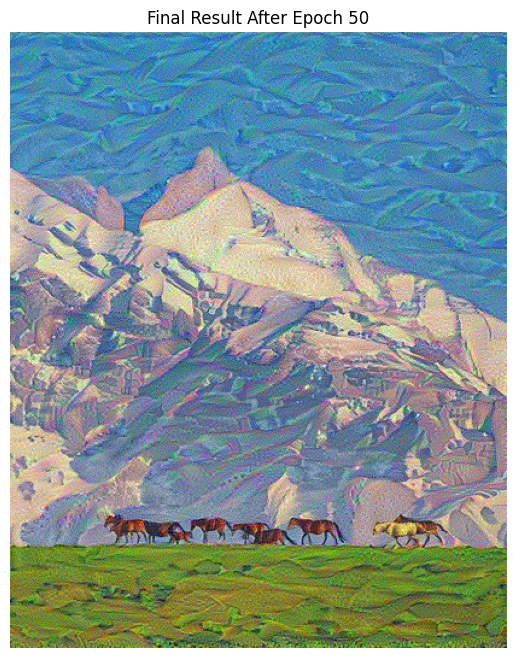

In [ ]:
# ------------------------------------------------------------
# Single Optimization Step (Gradient Descent Update)
# ------------------------------------------------------------
# This function performs one iteration of style transfer optimization:
# - Computes feature representations using VGG19 extractor
# - Calculates style, content, and total variation losses
# - Computes gradients of the total loss w.r.t. generated image
# - Updates the image using Adam optimizer

@tf.function
def train_step(image):
    """
    Executes one training step for neural style transfer optimization.
    """

    with tf.GradientTape() as tape:
        # Extract style and content features from current image
        outputs = extractor(image)

        # Compute style + content loss
        sc_loss, s_loss, c_loss = style_content_loss(outputs)

        # Compute total variation loss for smoothness regularization
        tv_loss = TV_WEIGHT * tf.reduce_mean(total_variation_loss(image))

        # Final optimization objective
        total_loss = sc_loss + tv_loss

    # Compute gradients of loss w.r.t. generated image pixels
    grad = tape.gradient(total_loss, image)

    # Apply gradient update using Adam optimizer
    optimizer.apply_gradients([(grad, image)])

    # Ensure pixel values remain in valid image range
    image.assign(tf.clip_by_value(image, 0.0, 255.0))

    return total_loss, s_loss, c_loss, tv_loss


# ------------------------------------------------------------
# Full Training Loop
# ------------------------------------------------------------
# Iteratively optimizes the generated image to minimize:
# - Style loss (texture alignment)
# - Content loss (structural similarity)
# - Total variation loss (spatial smoothness)

best_loss = float("inf")
best_image = None

step = 0

# History tracking for visualization and analysis
history_total = []
history_style = []
history_content = []
history_tv = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for i in range(STEPS_PER_EPOCH):
        step += 1

        # Perform one optimization step
        total_loss, style_loss_value, content_loss_value, tv_loss_value = train_step(generated_image)

        # Store loss history for later analysis
        history_total.append(float(total_loss))
        history_style.append(float(style_loss_value))
        history_content.append(float(content_loss_value))
        history_tv.append(float(tv_loss_value))

        # Track best generated image (lowest loss)
        if float(total_loss) < best_loss:
            best_loss = float(total_loss)
            best_image = generated_image.numpy()

        # Periodic logging for training monitoring
        if (i + 1) % 20 == 0:
            print(
                f"Step {step:4d} | "
                f"Total: {float(total_loss):.4f} | "
                f"Style: {float(style_loss_value):.4f} | "
                f"Content: {float(content_loss_value):.4f} | "
                f"TV: {float(tv_loss_value):.4f}"
            )

    # Visualize intermediate result after final epoch
    if epoch == EPOCHS - 1:
        current_img = tensor_to_image(generated_image)

        plt.figure(figsize=(8, 8))
        plt.imshow(current_img)
        plt.title(f"Final Result After Epoch {epoch+1}")
        plt.axis("off")
        plt.show()


Done.
Best loss: 2284933376.0
Saved to: /content/drive/MyDrive/vgg19_nst_result.png


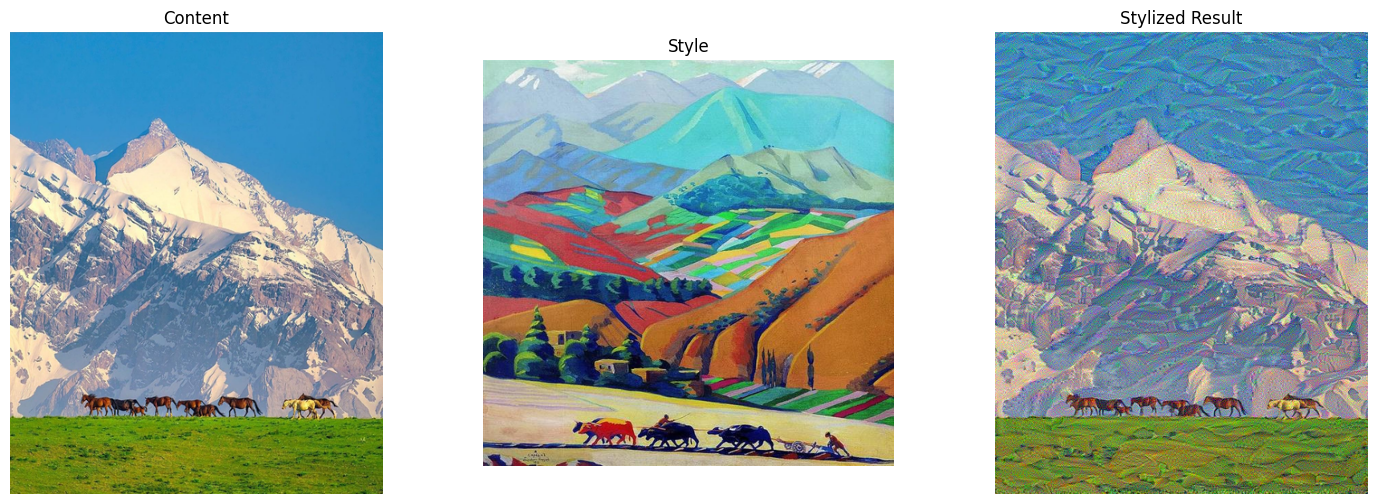

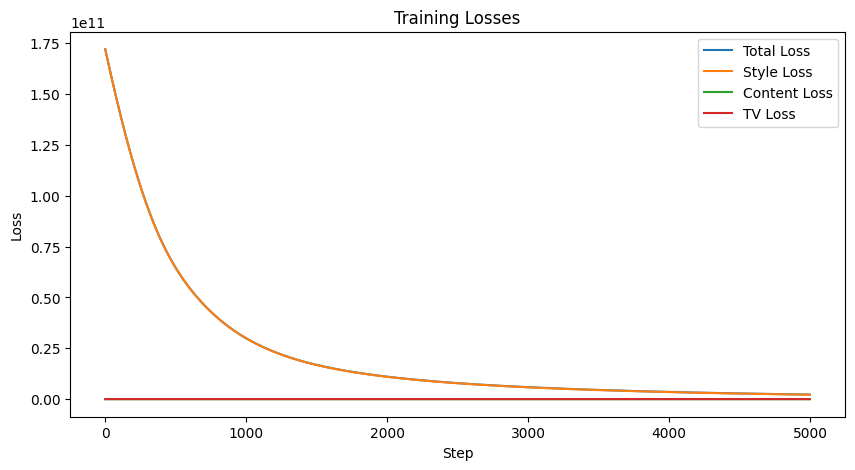

In [ ]:

# Save Best Generated Result

# The best generated image (with minimum total loss during optimization)
# is selected and saved to disk for further analysis or reporting.

best_result = np.clip(best_image[0], 0, 255).astype("uint8")

# Convert array to image and save to output path
Image.fromarray(best_result).save(OUTPUT_PATH)

print("\nTraining completed.")
print("Best loss achieved:", best_loss)
print("Final result saved to:", OUTPUT_PATH)



# Final Visualization of Results

# This section visualizes:
# - Original content image
# - Style reference image
# - Final stylized output image

plt.figure(figsize=(18, 6))

# Content image (input structure reference)
plt.subplot(1, 3, 1)
plt.imshow(tf.cast(content_image[0], tf.uint8))
plt.title("Content Image")
plt.axis("off")

# Style image (artistic reference)
plt.subplot(1, 3, 2)
plt.imshow(tf.cast(style_image[0], tf.uint8))
plt.title("Style Image")
plt.axis("off")

# Final stylized output
plt.subplot(1, 3, 3)
plt.imshow(best_result)
plt.title("Stylized Result")
plt.axis("off")

plt.show()



# Training Loss Visualization

# This plot shows the evolution of different loss components:
# - Total loss (optimization objective)
# - Style loss (texture alignment)
# - Content loss (structure preservation)
# - Total variation loss (smoothness regularization)

plt.figure(figsize=(10, 5))

plt.plot(history_total, label="Total Loss")
plt.plot(history_style, label="Style Loss")
plt.plot(history_content, label="Content Loss")
plt.plot(history_tv, label="TV Loss")

plt.legend()
plt.title("Training Loss Evolution")
plt.xlabel("Optimization Step")
plt.ylabel("Loss Value")

plt.show()